In [28]:
import os
import numpy as np
import pandas as pd

import warnings
warnings.filterwarnings('ignore')

from collections.abc import MutableMapping


from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier, 
                              AdaBoostClassifier)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

import time
import pickle as pkl
import matplotlib.pyplot as plt
import shap

In [2]:
path = r"data\fight_snapshots.parquet"
df = pd.read_parquet(path)
data = df.copy()

# Problem Statement: Predicting Fight Outcomes (F1 vs F2)

### **Objective**
The goal is to determine if **Fighter 1 (f1)** will win an upcoming match against **Fighter 2 (f2)** using only data available prior to the event.

---

### **1. Feature Engineering: Biometrics & Physicality**
We utilize the fundamental profiles for each athlete to establish their physical baseline:
* **Static Metrics:** Height, Weight, and Reach.
* **Temporal Metrics:** We use **Date of Birth** to calculate the exact **Age** of both fighters at the time of the bout.
* **Comparative Features:** We engineered "Delta" features to quantify the physical mismatch, such as **Age Difference**, **Weight Difference**, and **Reach Advantage**.

---

### **2. The Core Signal: Historical Performance**
The most critical component of the predictive model is the analysis of fighter history. We go beyond simple win/loss records by examining the *quality* of past performances:
* **Volume & Experience:** Total career fights and specific win/loss counts.
* **Engagement Dynamics:** Information on **Control Time**, **Total Duration**, and **Attack Metrics**.
* **Resilience Tracking:** By analyzing fight duration, we can distinguish between a "competitive loss" (a long fight that went to a decision) and a "swift loss" (an early finish).

---

### **3. Outcome-Conditional Aggregation**
To capture the nuances of a fighter's legacy, we bifurcated the historical data based on the result of past fights. Instead of a generic career average, we created separate statistical pools for **Won** and **Lost** history:

| Feature Subset | Aggregations | Strategic Purpose |
| :--- | :--- | :--- |
| **Won History** | `[mean, min, max]` | Highlights the fighter’s "Peak Efficiency" and winning style. |
| **Lost History** | `[mean, min, max]` | Identifies vulnerabilities and defensive durability under pressure. |

**Summary:** This approach expanded our feature space to **301 columns**, providing the model with the granularity needed to see what truly impacts the final prediction.

In [3]:
def flatten_dict(d, parent_key='', sep='_'):
    items = []
    for k, v in d.items():
        new_key = f"{parent_key}{sep}{k}" if parent_key else k
        
        if isinstance(v, MutableMapping):
            items.extend(flatten_dict(v, new_key, sep=sep).items())
        else:
            items.append((new_key, v))
    return dict(items)


def process(x):
    fight_date = pd.to_datetime(x["fight_date"])
    fighters = "f1,f2".split(",")
    stats = {k:{} for k in fighters}
    prior = {k:{} for k in fighters}
    diff = {}

    for i in fighters:
        dob = pd.to_datetime(x[f"{i}_dob"])
        stats[i]["age"] = int((fight_date - dob).days/30)
        stats[i]["height"] = x[f"{i}_height_in"]
        stats[i]["weight"] = x[f"{i}_weight_lbs"]
        stats[i]["reach"] = x[f"{i}_reach_in"]

        history = x[f"prior_{i}"]
        stats[i]["num_fights"] = len(history)

        results = [record["result"] for record in history]
        stats[i]["total_wins"] = len([j for j in results if j=="win"])
        stats[i]["total_loss"] = len([j for j in results if j=="loss"])

    for key in stats["f1"].keys():
        diff[f"diff_{key}"] = stats["f1"][key] - stats["f2"][key]

    def end_time(x):
        end_time = [int(i) for i in x["end_time"].split(":")]
        end_time[0] = end_time[0]*60
        end_time = sum(end_time)
        return end_time

    for i in fighters:
        history = x[f"prior_{i}"]


        wins = [end_time(record) for record in history if record["result"]=="win"]
        losses = [end_time(record) for record in history if record["result"]=="loss"]

        wins = [i for i in wins if isinstance(i, (int, float))]
        losses = [i for i in losses if isinstance(i, (int, float))]

        try:
            np.min(wins)
        except:
            wins = [0]
        try:
            np.min(losses)
        except:
            losses = [0]
            
        prior[i]["win_fights_lasted_mean_s"] = np.nan_to_num(np.mean(wins)).item()
        prior[i]["loss_fights_lasted_mean_s"] = np.nan_to_num(np.mean(losses)).item()
        prior[i]["win_fights_lasted_min_s"] = np.nan_to_num(np.min(wins)).item()
        prior[i]["loss_fights_lasted_min_s"] = np.nan_to_num(np.min(losses)).item()
        prior[i]["win_fights_lasted_max_s"] = np.nan_to_num(np.max(wins)).item()
        prior[i]["loss_fights_lasted_max_s"] = np.nan_to_num(np.max(losses)).item()

        features = []
        for record in history:
            for key in record.keys():
                if isinstance(record[key], (int, float)) and key[:4] != "opp_":
                    features.append(key)
            break

        for feature in features:
            wins = [record[feature] for record in history if record["result"]=="win"]
            losses = [record[feature] for record in history if record["result"]=="loss"]

            wins = [i for i in wins if isinstance(i, (int, float))]
            losses = [i for i in losses if isinstance(i, (int, float))]

            try:
                np.min(wins)
            except:
                wins = [0]
            try:
                np.min(losses)
            except:
                losses = [0]

            prior[i][f"win_{feature}_mean"] = np.nan_to_num(np.mean(wins)).item()
            prior[i][f"loss_{feature}_mean"] = np.nan_to_num(np.mean(losses)).item()
            prior[i][f"win_{feature}_min"] = np.nan_to_num(np.min(wins)).item()
            prior[i][f"loss_{feature}_min"] = np.nan_to_num(np.min(losses)).item()
            prior[i][f"win_{feature}_max"] = np.nan_to_num(np.max(wins)).item()
            prior[i][f"loss_{feature}_max"] = np.nan_to_num(np.max(losses)).item()

    final = {**flatten_dict(stats),  **diff, **flatten_dict(prior),}
    final["target"] = 1 if x["winner_id"] == x["fighter1_id"] else 0
    final["date"] = pd.to_datetime(x["fight_date"])
    
    return final

## Data Splitting & Validation Strategy

To maintain temporal integrity and prevent "data leakage," we implemented a strict chronological split rather than a random shuffle. This ensures the model is always trained on past data to predict future outcomes.

---

### **1. Temporal Train/Test Split**
The dataset was first sorted by date. We then partitioned the data using an 80/20 ratio:

* **Training Set:** The earliest **80%** of the data (**4,148 / 5,185 records**). This set was used for feature scaling, model training, and hyperparameter optimization.
* **Test Set:** The most recent **20%** of the data (**1,037 records**). This acts as a "true future" holdout set to evaluate how the model performs on unseen, upcoming fights.

### **2. Hyperparameter Tuning with TimeSeriesSplit**
Standard K-Fold Cross-Validation is unsuitable for this project because it shuffles the chronological order. Instead, we utilized **Grid Search** combined with **TimeSeriesSplit (5-Folds)**.



**The TimeSeriesSplit Advantage:**
* **Sequential Learning:** In each fold, the training indices are always lower (older) than the validation indices (newer).
* **Real-world Simulation:** It mimics the actual prediction environment where we only have access to historical data to make future inferences.

### **3. Final Evaluation**
The optimal hyperparameter configuration identified by the Grid Search was used to train a final model on the entire training block. This model was then evaluated on the **20% Test Set** to generate final performance metrics, including ROC-AUC, Accuracy, and F1-Score.

In [4]:
df = pd.DataFrame([process(x) for x in df.to_dict(orient="records")])
df = df.fillna(0.0)

df['date'] = pd.to_numeric(df['date'])
df = df.sort_values('date').reset_index(drop=True)

y = df['target']
X = df.drop(['target', 'date'], axis=1)

split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
y_train = y.iloc[:split_index]
X_test = X.iloc[split_index:]
y_test = y.iloc[split_index:]

print(f"Training set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")

Training set size: (4148, 309)
Test set size: (1037, 309)


## Modeling Suite: Algorithm Diversity

To identify the most robust predictor for fight outcomes, we evaluated **10 different machine learning architectures**. This selection covers a broad spectrum of mathematical approaches, from simple linear boundaries to complex ensemble methods and deep learning.

---

### **1. Linear & Instance-Based Models**
These models serve as our statistical baselines, focusing on feature relationships and spatial proximity:
* **Logistic Regression:** Our primary linear baseline, using $L_1$ or $L_2$ regularization to identify key feature weights.
* **Support Vector Machine (SVC):** Effective for finding the optimal hyperplane that separates winners from losers in high-dimensional space.
* **K-Nearest Neighbors (KNN):** A non-parametric approach that predicts outcomes based on the similarity of a fighter’s profile to past historical "neighbors."

### **2. Ensemble & Tree-Based Models**
These algorithms are highly effective for tabular data and capturing non-linear interactions between stats (e.g., how age impacts a fighter differently if they are a grappler vs. a striker):
* **Random Forest:** An ensemble of decision trees that reduces variance and prevents overfitting through bagging.
* **AdaBoost:** Focuses on "hard-to-predict" instances by weight-adjusting subsequent learners.
* **Gradient Boosting (GBM):** Sequentially builds trees to minimize the loss function.

### **3. State-of-the-Art Gradient Boosting (GBDT)**
We leveraged high-performance libraries optimized for speed and accuracy, utilizing **GPU acceleration** where applicable:
* **XGBoost:** Highly efficient and scalable implementation of gradient boosting with advanced regularization.
* **LightGBM:** Utilizes leaf-wise growth and histogram-based learning for faster training on our 301-feature dataset.
* **CatBoost:** Specifically designed to handle categorical features and reduce "prediction shift" during training.

### **4. Deep Learning**
* **Neural Network (MLP):** A Multi-Layer Perceptron used to capture complex, hidden hierarchies within the 301 features that traditional trees might miss.

---

### **Validation Goal**
Each model was piped through a **GridSearchCV** with **TimeSeriesSplit** to ensure that we aren't just picking the "most complex" model, but the one that generalizes best to the unseen 20% test set.

In [5]:
model_grids = {
    'Logistic Regression': {
        'pipeline': Pipeline([
            ('scaler', StandardScaler()), 
            ('classifier', LogisticRegression(solver='saga', max_iter=2000))
        ]),
        'params': {
            'classifier__C': [0.01, 0.1, 1, 10],
            'classifier__penalty': ['l1', 'l2']
        }
    },
    'SVC': {
        'pipeline': Pipeline([
            ('scaler', StandardScaler()), 
            ('classifier', SVC(probability=True, random_state=42))
        ]),
        'params': {
            'classifier__C': [0.1, 1, 10],
            'classifier__kernel': ['linear', 'rbf'],
            'classifier__gamma': ['scale', 'auto']
        }
    },
    'K-Nearest Neighbors': {
        'pipeline': Pipeline([
            ('scaler', StandardScaler()), 
            ('classifier', KNeighborsClassifier())
        ]),
        'params': {
            'classifier__n_neighbors': [3, 5, 7, 11],
            'classifier__weights': ['uniform', 'distance'],
            'classifier__p': [1, 2] # 1=Manhattan, 2=Euclidean
        }
    },
    'Neural Network (MLP)': {
        'pipeline': Pipeline([
            ('scaler', StandardScaler()), 
            ('classifier', MLPClassifier(max_iter=1000, random_state=42))
        ]),
        'params': {
            'classifier__hidden_layer_sizes': [(50,), (100,), (50, 25)],
            'classifier__activation': ['relu', 'tanh'],
            'classifier__alpha': [0.0001, 0.001, 0.01]
        }
    },
    'Random Forest': {
        'pipeline': Pipeline([
            ('classifier', RandomForestClassifier(random_state=42))
        ]),
        'params': {
            'classifier__n_estimators': [100, 300, 500],
            'classifier__max_depth': [None, 10, 20, 30],
            'classifier__min_samples_split': [2, 5, 10],
            'classifier__max_features': ['sqrt', 'log2']
        }
    },
    'Gradient Boosting': {
        'pipeline': Pipeline([
            ('classifier', GradientBoostingClassifier(random_state=42))
        ]),
        'params': {
            'classifier__n_estimators': [100, 200],
            'classifier__learning_rate': [0.01, 0.1, 0.2],
            'classifier__max_depth': [3, 5, 7]
        }
    },
    'AdaBoost': {
        'pipeline': Pipeline([
            ('classifier', AdaBoostClassifier(random_state=42))
        ]),
        'params': {
            'classifier__n_estimators': [50, 100, 200],
            'classifier__learning_rate': [0.01, 0.1, 1.0]
        }
    },
    'XGBoost': {
        'pipeline': Pipeline([
            ('classifier', XGBClassifier(
                use_label_encoder=False, 
                eval_metric='logloss', 
                random_state=42, 
                tree_method='hist', 
                device='cuda'
            ))
        ]),
        'params': {
            'classifier__n_estimators': [100, 300, 500, 1000, 2000],
            'classifier__learning_rate': [0.01, 0.1, 0.2],
            'classifier__max_depth': [3, 6, 9],
            'classifier__colsample_bytree': [0.6, 0.8, 1.0]
        }
    },
    'LightGBM': {
        'pipeline': Pipeline([
            ('classifier', LGBMClassifier(
                random_state=42, 
                verbose=-1, 
                device_type='gpu'
            ))
        ]),
        'params': {
            'classifier__n_estimators': [100, 300, 500, 1000, 2000],
            'classifier__learning_rate': [0.01, 0.1, 0.2],
            'classifier__num_leaves': [31, 50, 100],
            'classifier__subsample': [0.8, 1.0]
        }
    },
    'CatBoost': {
        'pipeline': Pipeline([
            ('classifier', CatBoostClassifier(
                verbose=0, 
                random_state=42, 
                task_type='GPU'
            ))
        ]),
        'params': {
            'classifier__iterations': [100, 300, 500, 1000, 2000],
            'classifier__learning_rate': [0.01, 0.1],
            'classifier__depth': [4, 6, 8]
        }
    }
}

if not os.path.isfile("cache/grid_results.pkl"):

    tscv = TimeSeriesSplit(n_splits=5)

    grid_results = []
    results_list = []
    fitted_models = {}

    for model_name, config in model_grids.items():
        print(f"--- Training {model_name} ---")
        start_time = time.time()
        
        grid_search = GridSearchCV(
            estimator=config['pipeline'],
            param_grid=config['params'],
            cv=tscv,              
            scoring='roc_auc', 
            n_jobs= 1 if ("cat" in model_name.lower() or "light" in model_name.lower()) else -1,             
            verbose=1
        )
        
        grid_search.fit(X_train, y_train)
        end_time = time.time()
        
        best_model = grid_search.best_estimator_
        y_pred = best_model.predict(X_test)
        
        if hasattr(best_model, "predict_proba"):
            y_proba = best_model.predict_proba(X_test)[:, 1]
        else:
            y_proba = best_model.decision_function(X_test)
        
        test_roc_auc = roc_auc_score(y_test, y_proba)
        test_accuracy = accuracy_score(y_test, y_pred)
        
        results_list.append({
            'Model': model_name,
            'Best CV ROC-AUC': round(grid_search.best_score_, 4),
            'Test ROC-AUC': round(test_roc_auc, 4),
            'Test Accuracy': round(test_accuracy, 4),
            'Fit Time (s)': round(end_time - start_time, 2),
            'Best Parameters': grid_search.best_params_
        })
        
        fitted_models[model_name] = best_model
        
        grid_result = pd.DataFrame(grid_search.cv_results_).sort_values("rank_test_score", ignore_index=True)
        grid_results.append(grid_result)
        display(grid_result)

        with open("cache/grid_results.pkl", "wb") as file:
            pkl.dump([grid_results, results_list, fitted_models], file)

else:
    with open("cache/grid_results.pkl", "rb") as file:
            grid_results, results_list, fitted_models = pkl.load(file)

    for (model_name, config), grid_result in zip(model_grids.items(), grid_results):
        print(f"--- Training {model_name} ---")
        display(grid_result)

--- Training Logistic Regression ---


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_classifier__C,param_classifier__penalty,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.447101,0.213951,0.005502,0.001096,0.01,l2,"{'classifier__C': 0.01, 'classifier__penalty':...",0.643382,0.598259,0.565506,0.603093,0.625083,0.607064,0.026321,1
1,2.049453,0.979526,0.005403,0.000582,0.10,l1,"{'classifier__C': 0.1, 'classifier__penalty': ...",0.636748,0.603270,0.575790,0.601415,0.617138,0.606872,0.020034,2
2,2.325790,1.231835,0.005006,0.000445,0.10,l2,"{'classifier__C': 0.1, 'classifier__penalty': ...",0.627129,0.574291,0.566274,0.586589,0.614693,0.593795,0.023399,3
3,13.356929,6.260374,0.004504,0.000314,1.00,l1,"{'classifier__C': 1, 'classifier__penalty': 'l1'}",0.611750,0.561695,0.566440,0.577990,0.612868,0.586149,0.022011,4
4,11.455962,5.883090,0.004699,0.000598,1.00,l2,"{'classifier__C': 1, 'classifier__penalty': 'l2'}",0.601622,0.551958,0.565331,0.567832,0.606723,0.578693,0.021553,5
5,13.922069,6.550748,0.004803,0.000511,10.00,l1,"{'classifier__C': 10, 'classifier__penalty': '...",0.590433,0.549259,0.564248,0.562489,0.605186,0.574323,0.020405,6
6,12.475926,5.889457,0.004694,0.000394,10.00,l2,"{'classifier__C': 10, 'classifier__penalty': '...",0.589161,0.548823,0.564353,0.561686,0.603608,0.573526,0.019919,7
7,0.564790,0.373928,0.007582,0.002071,0.01,l1,"{'classifier__C': 0.01, 'classifier__penalty':...",0.500000,0.540347,0.565392,0.590669,0.619073,0.563096,0.040982,8


--- Training SVC ---


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_classifier__C,param_classifier__gamma,param_classifier__kernel,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,4.885766,5.231645,0.276700,0.194328,1.0,auto,rbf,"{'classifier__C': 1, 'classifier__gamma': 'aut...",0.618977,0.555226,0.586642,0.598178,0.599711,0.591747,0.021005,1
1,4.798187,5.265611,0.304284,0.177283,1.0,scale,rbf,"{'classifier__C': 1, 'classifier__gamma': 'sca...",0.618977,0.555226,0.586642,0.598178,0.599711,0.591747,0.021005,1
2,5.746526,5.870535,0.331411,0.188046,0.1,scale,rbf,"{'classifier__C': 0.1, 'classifier__gamma': 's...",0.627545,0.549921,0.544831,0.607543,0.601698,0.586308,0.032962,3
3,6.114692,6.888419,0.324551,0.155382,0.1,auto,rbf,"{'classifier__C': 0.1, 'classifier__gamma': 'a...",0.627545,0.549921,0.544831,0.607543,0.601698,0.586308,0.032962,3
4,5.491185,4.980636,0.168454,0.169777,0.1,auto,linear,"{'classifier__C': 0.1, 'classifier__gamma': 'a...",0.608807,0.559525,0.562179,0.575482,0.602181,0.581635,0.020326,5
5,6.962969,6.475678,0.134853,0.115609,0.1,scale,linear,"{'classifier__C': 0.1, 'classifier__gamma': 's...",0.608807,0.559525,0.562179,0.575482,0.602181,0.581635,0.020326,5
6,21.993535,16.380689,0.062420,0.025812,1.0,scale,linear,"{'classifier__C': 1, 'classifier__gamma': 'sca...",0.573154,0.548932,0.555727,0.569072,0.594593,0.568296,0.015803,7
7,21.188359,15.650582,0.061230,0.026146,1.0,auto,linear,"{'classifier__C': 1, 'classifier__gamma': 'aut...",0.573154,0.548932,0.555727,0.569072,0.594593,0.568296,0.015803,7
8,240.876623,156.233584,0.053248,0.028781,10.0,scale,linear,"{'classifier__C': 10, 'classifier__gamma': 'sc...",0.560854,0.565668,0.561324,0.560273,0.591724,0.567968,0.012030,9
9,239.879760,155.726400,0.051700,0.026691,10.0,auto,linear,"{'classifier__C': 10, 'classifier__gamma': 'au...",0.560854,0.565668,0.561324,0.560273,0.591724,0.567968,0.012030,9


--- Training K-Nearest Neighbors ---


...

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_classifier__colsample_bytree,param_classifier__learning_rate,param_classifier__max_depth,param_classifier__n_estimators,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,24.938855,0.173223,0.317299,0.005319,0.6,0.01,6,500,"{'classifier__colsample_bytree': 0.6, 'classif...",0.608399,0.577082,0.577030,0.604753,0.613989,0.596250,0.015946,1
1,26.677370,0.299353,0.330486,0.010243,0.8,0.01,6,500,"{'classifier__colsample_bytree': 0.8, 'classif...",0.610732,0.582210,0.563061,0.602263,0.620660,0.595785,0.020685,2
2,14.626672,0.102314,0.189720,0.011219,0.6,0.01,6,300,"{'classifier__colsample_bytree': 0.6, 'classif...",0.607170,0.576638,0.572027,0.606002,0.616662,0.595700,0.017893,3
3,16.085408,0.267433,0.211023,0.006133,0.8,0.01,6,300,"{'classifier__colsample_bytree': 0.8, 'classif...",0.608976,0.582055,0.559254,0.607114,0.617121,0.594904,0.021339,4
4,56.624716,3.700700,0.421561,0.028131,0.8,0.01,9,500,"{'classifier__colsample_bytree': 0.8, 'classif...",0.609536,0.583652,0.568544,0.607215,0.605475,0.594884,0.016117,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
130,55.636406,0.763822,1.304302,0.038864,1.0,0.20,3,2000,"{'classifier__colsample_bytree': 1.0, 'classif...",0.570482,0.547089,0.542361,0.594367,0.561994,0.563258,0.018545,131
131,27.401841,0.076339,0.571389,0.005538,0.6,0.20,3,1000,"{'classifier__colsample_bytree': 0.6, 'classif...",0.577285,0.543376,0.537803,0.573832,0.583804,0.563220,0.018836,132
132,65.024787,0.566175,1.341337,0.067579,0.8,0.10,3,2000,"{'classifier__colsample_bytree': 0.8, 'classif...",0.575983,0.536990,0.538048,0.582850,0.573109,0.561396,0.019754,133
133,59.023351,2.179680,1.305099,0.071481,0.8,0.20,3,2000,"{'classifier__colsample_bytree': 0.8, 'classif...",0.577998,0.544063,0.528575,0.580653,0.573916,0.561041,0.020881,134


--- Training LightGBM ---


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_classifier__learning_rate,param_classifier__n_estimators,param_classifier__num_leaves,param_classifier__subsample,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,2.458803,0.574161,0.005200,0.000400,0.01,300,50,1.0,"{'classifier__learning_rate': 0.01, 'classifie...",0.608230,0.587934,0.552427,0.605145,0.617545,0.594256,0.023004,1
1,2.553674,0.601156,0.005001,0.000632,0.01,300,50,0.8,"{'classifier__learning_rate': 0.01, 'classifie...",0.608187,0.587733,0.552357,0.604825,0.617562,0.594133,0.023009,2
2,1.677186,0.202916,0.004201,0.000401,0.01,300,31,1.0,"{'classifier__learning_rate': 0.01, 'classifie...",0.608306,0.574484,0.559630,0.598315,0.625787,0.593304,0.023637,3
3,1.713901,0.224859,0.005111,0.000675,0.01,300,31,0.8,"{'classifier__learning_rate': 0.01, 'classifie...",0.608137,0.574517,0.559350,0.598342,0.625838,0.593237,0.023705,4
4,6.172160,2.691009,0.005403,0.000586,0.01,500,100,0.8,"{'classifier__learning_rate': 0.01, 'classifie...",0.602648,0.576939,0.565925,0.601278,0.619158,0.593190,0.019166,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85,3.064462,1.192004,0.005400,0.000799,0.20,1000,50,0.8,"{'classifier__learning_rate': 0.2, 'classifier...",0.599493,0.545111,0.563585,0.589798,0.562805,0.572158,0.019753,86
86,3.011119,1.202246,0.005401,0.000801,0.20,1000,50,1.0,"{'classifier__learning_rate': 0.2, 'classifier...",0.598950,0.544265,0.563908,0.590127,0.562652,0.571980,0.019885,87
87,3.706563,1.381414,0.006965,0.001013,0.20,2000,50,1.0,"{'classifier__learning_rate': 0.2, 'classifier...",0.597253,0.546024,0.563419,0.589543,0.563186,0.571885,0.018823,88
88,0.589530,0.048436,0.004101,0.000203,0.20,100,31,1.0,"{'classifier__learning_rate': 0.2, 'classifier...",0.599857,0.536563,0.546071,0.593865,0.577039,0.570679,0.025294,89


--- Training CatBoost ---


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_classifier__depth,param_classifier__iterations,param_classifier__learning_rate,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,2.941258,0.074921,0.008713,0.000881,8,300,0.01,"{'classifier__depth': 8, 'classifier__iteratio...",0.615389,0.573051,0.584503,0.609093,0.602640,0.596935,0.015786,1
1,1.630056,0.024917,0.007606,0.000492,4,300,0.01,"{'classifier__depth': 4, 'classifier__iteratio...",0.622523,0.571090,0.578147,0.591120,0.615635,0.595703,0.020256,2
2,2.026720,0.028257,0.008716,0.001750,6,300,0.01,"{'classifier__depth': 6, 'classifier__iteratio...",0.613922,0.563883,0.580906,0.598269,0.614532,0.594302,0.019569,3
3,29.876033,0.560846,0.008607,0.000490,8,500,0.01,"{'classifier__depth': 8, 'classifier__iteratio...",0.606296,0.564838,0.585071,0.601962,0.610653,0.593764,0.016863,4
4,1.433579,0.046057,0.009036,0.001291,8,100,0.01,"{'classifier__depth': 8, 'classifier__iteratio...",0.625645,0.563372,0.573669,0.599874,0.604456,0.593403,0.022338,5
5,11.969063,0.148395,0.008322,0.000411,6,500,0.01,"{'classifier__depth': 6, 'classifier__iteratio...",0.596804,0.565860,0.587978,0.601762,0.608293,0.592139,0.014719,6
6,1.089244,0.015117,0.008947,0.001404,6,100,0.01,"{'classifier__depth': 6, 'classifier__iteratio...",0.622845,0.563003,0.564929,0.594841,0.610856,0.591295,0.024026,7
7,8.958243,0.115062,0.008472,0.000780,4,500,0.01,"{'classifier__depth': 4, 'classifier__iteratio...",0.606364,0.562207,0.581186,0.593336,0.613360,0.591291,0.018256,8
8,0.950948,0.020098,0.007007,0.000541,4,100,0.01,"{'classifier__depth': 4, 'classifier__iteratio...",0.632609,0.562525,0.563445,0.583087,0.614778,0.591289,0.028032,9
9,23.475819,0.425337,0.010977,0.002692,6,1000,0.01,"{'classifier__depth': 6, 'classifier__iteratio...",0.592885,0.563095,0.589008,0.598133,0.606332,0.589891,0.014601,10


# Model Performance & Tuning Results

The table below summarizes the performance metrics for all evaluated models, sorted by their predictive power on the unseen test set.

### **1. Performance Summary Table**

| Model | Best CV ROC-AUC | Test ROC-AUC | Test Accuracy | Fit Time (s) |
| :--- | :---: | :---: | :---: | :---: |
| **Logistic Regression** | **0.6071** | **0.6348** | **58.73%** | 29.91 |
| **LightGBM** | 0.5943 | 0.6319 | 58.05% | 1883.14 |
| **CatBoost** | 0.5969 | 0.6264 | 55.74% | 3629.90 |
| **XGBoost** | 0.5963 | 0.6263 | 57.76% | 1349.49 |
| **SVC** | 0.5917 | 0.6112 | 56.22% | 483.82 |
| **Random Forest** | 0.5925 | 0.6102 | 56.32% | 51.80 |
| **Gradient Boosting** | 0.5865 | 0.6019 | 56.80% | 113.21 |
| **AdaBoost** | 0.5847 | 0.5991 | 51.78% | 19.78 |
| **Neural Network (MLP)** | 0.5737 | 0.5746 | 56.12% | 29.63 |
| **K-Nearest Neighbors** | 0.5447 | 0.5268 | 49.28% | 3.83 |

---

### **2. Analysis of the Top Performer: Logistic Regression**
Surprisingly, **Logistic Regression** outperformed the more complex ensemble models (XGBoost, LightGBM). This suggests that the relationship between our 301 features and the fight outcome is largely linear, or that the ensembles are over-fitting to the noise inherent in MMA data.

**Key Metrics for Logistic Regression:**
* **Generalization:** The Test ROC-AUC (0.6348) is actually higher than the CV ROC-AUC (0.6071), indicating a very stable and well-generalized model.
* **Class Balance:** * **Precision for Class 0 (Losses):** 0.70 — The model is quite reliable when it predicts a loss.
    * **Recall for Class 1 (Wins):** 0.64 — The model is effective at catching the majority of winning outcomes for Fighter 1.

---

### **3. Optimized Hyperparameters**
The Grid Search identified the following "Best Estimator" configurations for our top 4 architectures:

* **Logistic Regression:** `{'C': 0.01, 'penalty': 'l2'}` — Strong regularization was key to preventing overfitting on the high-dimensional feature space.
* **LightGBM:** `{'learning_rate': 0.01, 'n_estimators': 300, 'num_leaves': 50}`
* **CatBoost:** `{'depth': 8, 'iterations': 300, 'learning_rate': 0.01}`
* **XGBoost:** `{'colsample_bytree': 0.6, 'learning_rate': 0.01, 'max_depth': 6, 'n_estimators': 500}`

---

### **💡 Final Insight**
All models achieved comparable results (ROC-AUC 0.60–0.63), suggesting a "performance ceiling" for the current feature set. The fact that Logistic Regression is the leader provides a lightweight, highly interpretable solution for predicting fight winners.

In [6]:
results_df = pd.DataFrame(results_list)
results_df = results_df.sort_values(by='Test ROC-AUC', ascending
                                    =False).reset_index(drop=True)


pd.set_option('display.max_colwidth', None)
print("\n" + "="*80)
print("GRID SEARCH RESULTS SUMMARY")
print("="*80)
print(results_df[['Model', 'Best CV ROC-AUC', 'Test ROC-AUC', 'Test Accuracy', 'Fit Time (s)']].to_string(index=False))

print("\n" + "="*80)
print("BEST PARAMETERS PER MODEL")
print("="*80)
for index, row in results_df.iterrows():
    print(f"\n{row['Model']}:")
    
    cleaned_params = {k.replace('classifier__', ''): v for k, v in row['Best Parameters'].items()}
    print(cleaned_params)

best_overall_name = results_df.iloc[0]['Model']
print(f"\nDetailed Classification Report for Top Model: {best_overall_name}")
print(classification_report(y_test, fitted_models[best_overall_name].predict(X_test)))


GRID SEARCH RESULTS SUMMARY
               Model  Best CV ROC-AUC  Test ROC-AUC  Test Accuracy  Fit Time (s)
 Logistic Regression           0.6071        0.6348         0.5873         29.91
            LightGBM           0.5943        0.6319         0.5805       1883.14
            CatBoost           0.5969        0.6264         0.5574       3629.90
             XGBoost           0.5963        0.6263         0.5776       1349.49
                 SVC           0.5917        0.6112         0.5622        483.82
       Random Forest           0.5925        0.6102         0.5632         51.80
   Gradient Boosting           0.5865        0.6019         0.5680        113.21
            AdaBoost           0.5847        0.5991         0.5178         19.78
Neural Network (MLP)           0.5737        0.5746         0.5612         29.63
 K-Nearest Neighbors           0.5447        0.5268         0.4928          3.83

BEST PARAMETERS PER MODEL

Logistic Regression:
{'C': 0.01, 'penalty': 'l2'}

L

## Results: Feature Importance Comparison

To understand what drives our model predictions, we analyzed the **top 30 features** from our four best-performing models: **Logistic Regression, LightGBM, CatBoost, and XGBoost**.

### **1. The Dominance of Physical Metrics**
Across all models, biometric and comparative features emerge as the strongest predictors:
* **Age Dynamics:** `diff_age` and individual fighter ages (`f1_age`, `f2_age`) are consistently at the top of the importance rankings. This suggests the models heavily weight the "youth advantage" or physical peak of an athlete.
* **Physical Leverage:** **Reach** (`f1_reach`, `diff_reach`) and **Height** differences appear as secondary but critical factors, especially in the linear Logistic Regression model.

### **2. Behavioral & Style Insights from History**
Beyond raw physical stats, the models successfully identified specific fighting styles and tendencies from the historical data:
* **Ground Game & Control:** Features like `f1_win_ground_landed_mean` and `f2_win_ctrl_time_s_max` show that the model values a fighter's ability to dominate on the mat.
* **Striking Volume:** High importance is placed on attempt metrics (e.g., `f2_win_total_str_attempts_max`), indicating that offensive output is a key indicator of a potential winner.
* **Durability & Finish Rates:** The inclusion of fight duration metrics (e.g., `f1_loss_fights_lasted_min_s`) suggests the models are learning to identify which fighters are "hard to finish" versus those who succumb quickly.

### **3. Model Consistency**
While the exact ordering varies, there is significant overlap between the ensemble methods (LightGBM, CatBoost, XGBoost). This consensus reinforces that the engineered features—particularly the **Outcome-Conditional Aggregates** (bifurcated Win/Loss stats)—effectively captured the signal needed to differentiate between world-class athletes.

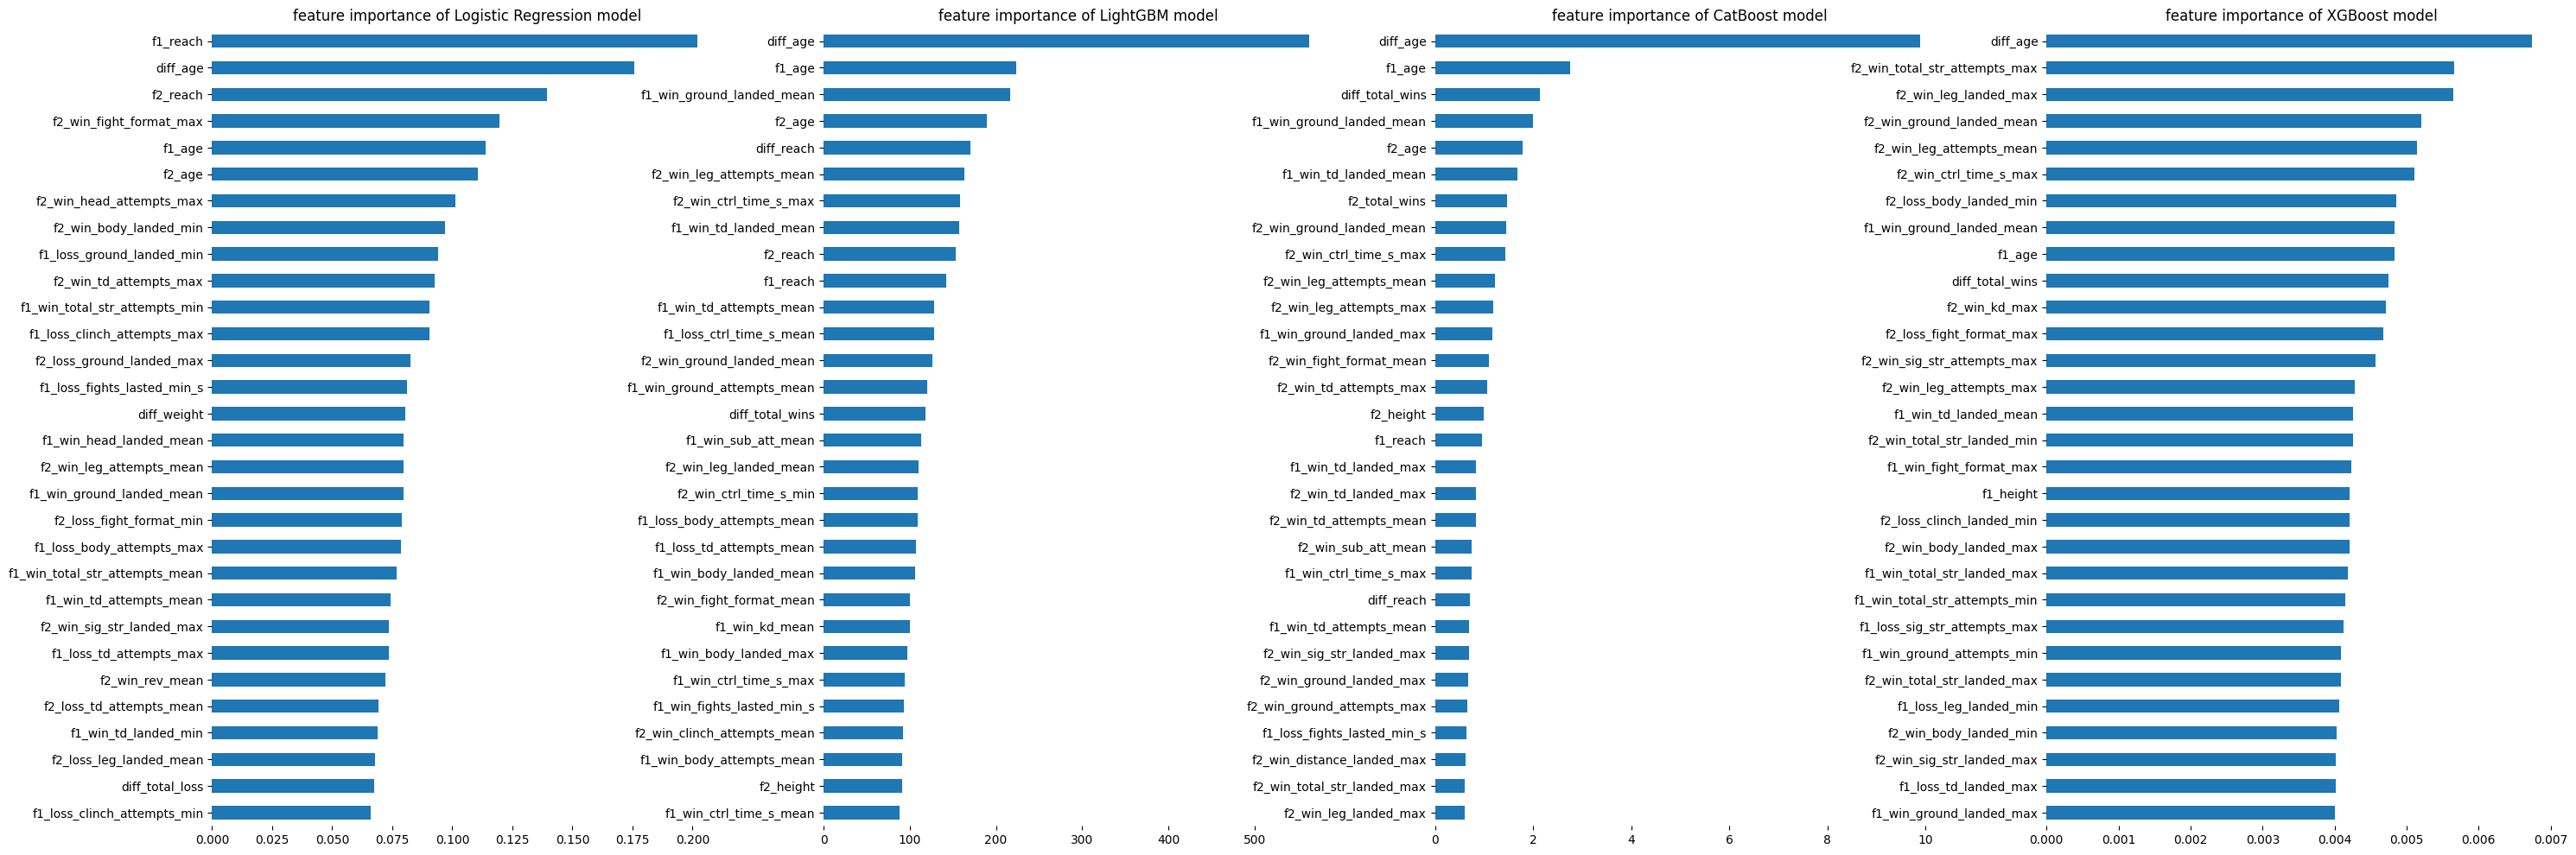

In [7]:
#save
plt.figure(figsize=(35, 12))
for e, model_name in enumerate("Logistic Regression,LightGBM,CatBoost,XGBoost".split(","), 1):
    pipe = fitted_models[model_name]
    if model_name == "Logistic Regression":
        importance = pipe.named_steps['classifier'].coef_[0]
    else:
        importance = pipe.named_steps['classifier'].feature_importances_
        importance = pd.Series(importance, index=X.columns)
        
    features = pipe[:-1].get_feature_names_out()
    importance = pd.Series(importance, index=features).sort_values(ascending=False)
    ax = plt.subplot(1,4,e)
    importance.to_frame().assign(temp=lambda x: x[0].abs()).sort_values(by="temp", ignore_index=False).iloc[-30:, :].loc[:, 0].abs().sort_values(ignore_index=False).plot.barh(ax=ax)
    for spine in ax.spines.values():
        spine.set_visible(False)
    plt.title(f"feature importance of {model_name} model")
    

In [43]:
y_proba = fitted_models["LightGBM"].predict_proba(X_test)[:, 1]
y_pred = fitted_models["LightGBM"].predict(X_test)
results = X_test.copy()
# results = data.loc[X_test.index].copy()

results['target'] = y_test
results['pred'] = y_pred
results['proba'] = y_proba


results['error_mag'] = np.where(results['target'] == 1, 1 - results['proba'], results['proba'])
errors = results[results['target'] != results['pred']].sort_values(by='error_mag', ascending=False)
errors.head(10)

,f1_age,f1_height,f1_weight,f1_reach,f1_num_fights,f1_total_wins,f1_total_loss,f2_age,f2_height,f2_weight,...,f2_win_total_str_landed_mean,f2_loss_total_str_landed_mean,f2_win_total_str_landed_min,f2_loss_total_str_landed_min,f2_win_total_str_landed_max,f2_loss_total_str_landed_max,target,pred,proba,error_mag
5159,393,72,185,75.0,11,9,2,425,73,185,...,112.437500,81.857143,24.0,14.0,221.0,183.0,0,1,0.838424,0.838424
4548,391,69,125,68.0,9,6,3,300,67,125,...,55.500000,0.000000,5.0,0.0,121.0,0.0,1,0,0.175328,0.824672
4898,281,70,170,69.0,4,1,3,433,73,170,...,0.000000,49.000000,0.0,21.0,0.0,67.0,0,1,0.819096,0.819096
4516,444,65,125,66.0,16,12,4,378,65,125,...,130.875000,118.500000,50.0,21.0,193.0,262.0,1,0,0.197979,0.802021
5101,292,69,125,71.0,3,2,1,434,67,125,...,88.000000,68.500000,50.0,63.0,115.0,74.0,0,1,0.796643,0.796643
4956,421,69,125,70.0,11,6,5,319,66,125,...,44.666667,0.000000,12.0,0.0,71.0,0.0,1,0,0.206962,0.793038
4522,435,66,125,66.0,2,0,2,410,68,125,...,127.000000,82.000000,94.0,52.0,178.0,102.0,1,0,0.209775,0.790225
5180,295,67,145,68.0,5,4,1,499,66,145,...,60.300000,38.666667,2.0,0.0,136.0,89.0,0,1,0.772492,0.772492
5002,367,69,145,72.0,14,8,6,393,67,145,...,0.000000,38.000000,0.0,19.0,0.0,57.0,0,1,0.766572,0.766572
4159,472,66,145,70.0,13,9,4,355,70,135,...,68.000000,46.000000,24.0,46.0,182.0,46.0,1,0,0.237519,0.762481


## Error Analysis: SHAP Beeswarm Interpretation
**Focus:** Analysis of feature impact on misclassified instances ($y_{test} \neq y_{pred}$).

### 1. Primary Drivers of Inaccuracy
* **Age Bias (`diff_age`, `f1_age`):** * **Observation:** Significant clusters of high values (red) are pushing predictions strongly toward a specific class in error cases.
    * **Insight:** The model appears to be over-relying on age as a heuristic. It is "blind" to veteran fighters who overcome the age gap through technical proficiency.
* **Ground Game Overestimation (`f1_win_ground_landed_mean`):**
    * **Observation:** High ground strike counts are tricking the model into confident Class 1 predictions that turn out to be wrong.
    * **Insight:** The model values volume over position or submission risk. It may be missing "get-up" rates or submission threats that negate ground control.

### 2. Physical & Format Anomalies
* **Reach Neutralization (`diff_reach`):** High reach advantages for F1 are leading to confident but incorrect Class 1 predictions. The model fails to account for fighters who effectively "close the distance."
* **Format Sensitivity (`f2_win_fight_format_mean`):** The model is improperly penalizing or rewarding fighters based on the 3 vs. 5 round format, likely missing "Championship Cardio" nuances.

### Proposed Action Plan
| Issue | Potential Fix |
| :--- | :--- |
| **Age Overfitting** | Apply non-linear scaling to age features or create "Veteran Status" bins. |
| **Ground Volume Bias** | Introduce "Submission Defense" or "Grappling Accuracy" to contextualize landed strikes. |
| **Reach Neutralization** | Feature engineering: Calculate "Leg Kick Frequency" or "Clinch Time" to see how reach is mitigated. |
| **Confidence Calibration** | Since the model is "confidently wrong," consider adjusting the classification threshold from 0.5. |

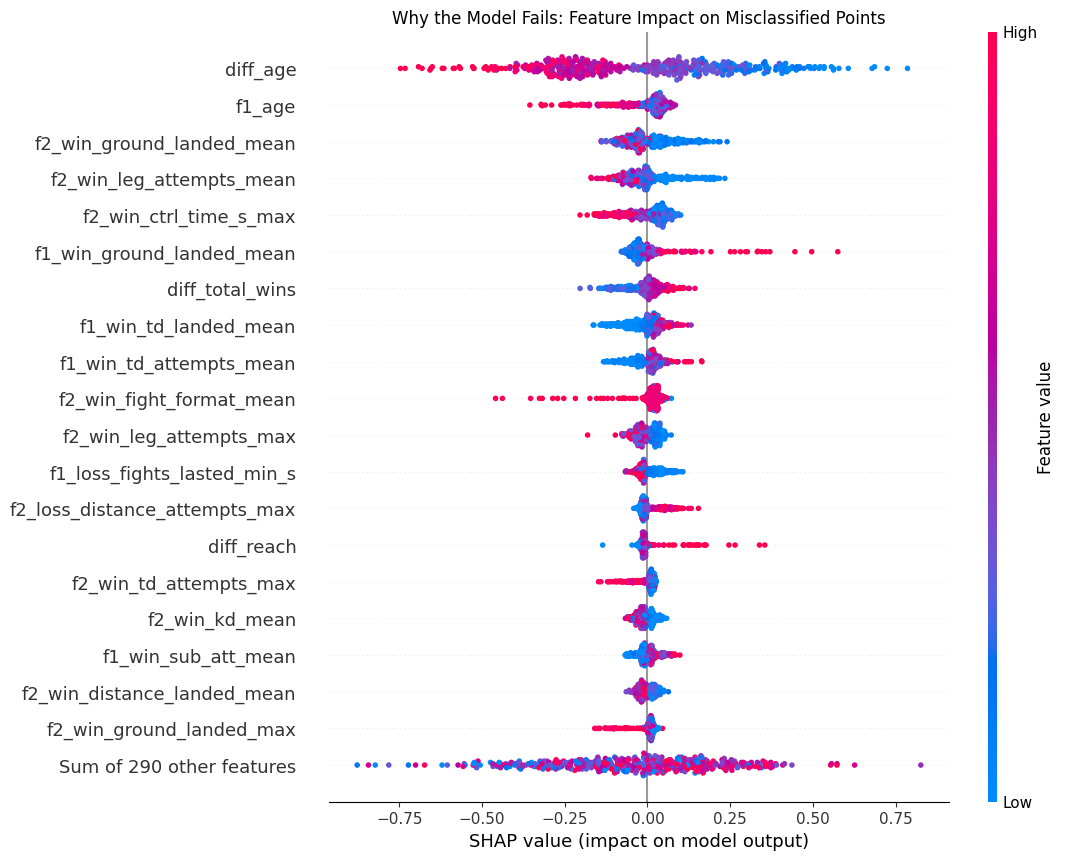

In [60]:
explainer = shap.Explainer(fitted_models["LightGBM"].named_steps['classifier'])
shap_values = explainer(X_test)

error_mask = (y_test.values.flatten() != y_pred.flatten())
# We select the SHAP values corresponding to those specific error rows
shap_values_errors = shap_values[error_mask]

plt.figure(figsize=(10, 10))
ax = plt.subplot(1,1,1)
ax.set_title("Why the Model Fails: Feature Impact on Misclassified Points")
shap.plots.beeswarm(shap_values_errors, max_display=20, ax=ax, plot_size=None)



